In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
from sklearn.model_selection import train_test_split

BASE_DIR = Path("/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean")
RNG_SEED = 42
fs = 125
window_size = 250
window_stride = 125

bands = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

def parse_label_from_path(p: str) -> str:
    s = p.lower().replace("_", "").replace("-", "").replace(" ", "")
    if "backward" in s or "backwards" in s:
        return "backward"
    if "fowward" in s or "forward" in s:
        return "forward"
    if "landing" in s or "land" in s:
        return "landing"
    if "left" in s:
        return "left"
    if "right" in s:
        return "right"
    if "takeoff" in s or "takeoff" in s:
        return "takeoff"
    return ""

def load_exg16(fp: Path):
    parse_attempts = [
        dict(sep=r"\s*,\s*", engine="python", comment="%", on_bad_lines="skip"),
        dict(sep="\t", engine="python", header=None, on_bad_lines="skip"),
        dict(sep=",", engine="python", header=None, on_bad_lines="skip"),
    ]
    for kw in parse_attempts:
        try:
            df = pd.read_csv(fp, **kw)
            if df is None or df.empty:
                continue
            exg_named = [c for c in df.columns if "exg channel" in str(c).lower()]
            if len(exg_named) >= 16:
                exg = df[exg_named[:16]].copy()
            elif df.shape[1] >= 17:
                exg = df.iloc[:, 1:17].copy()
            elif df.shape[1] >= 16:
                exg = df.iloc[:, :16].copy()
            else:
                continue
            exg = exg.apply(pd.to_numeric, errors="coerce")
            exg = exg.replace([np.inf, -np.inf], np.nan).dropna(how="all")
            if exg.shape[0] == 0:
                continue
            exg.columns = [f"EXG Channel {i}" for i in range(16)]
            return exg
        except Exception:
            continue
    return None

all_files = list(BASE_DIR.rglob("*.txt")) + list(BASE_DIR.rglob("*.csv"))
rows = []
for fp in all_files:
    exg = load_exg16(fp)
    if exg is None:
        continue
    lbl = parse_label_from_path(str(fp))
    if lbl == "":
        continue
    exg["src_filename"] = str(fp)
    exg["label_txt"] = lbl
    rows.append(exg)

eeg_data = pd.concat(rows, ignore_index=True)
exg_cols = [f"EXG Channel {i}" for i in range(16)]

file_label = eeg_data.groupby("src_filename")["label_txt"].agg(lambda s: s.mode().iat[0])
files = file_label.index.to_numpy()
label_names = sorted(pd.unique(file_label.values).tolist())
label_to_id = {lbl: i for i, lbl in enumerate(label_names)}
file_labels = np.array([label_to_id[file_label.loc[f]] for f in files], dtype=np.int32)

trainval_files, test_files = train_test_split(files, test_size=0.2, random_state=RNG_SEED, stratify=file_labels)
trainval_labels = np.array([label_to_id[file_label.loc[f]] for f in trainval_files], dtype=np.int32)
train_files, val_files = train_test_split(trainval_files, test_size=0.25, random_state=RNG_SEED, stratify=trainval_labels)

train_rows = eeg_data[eeg_data["src_filename"].isin(set(train_files))]
train_medians = train_rows[exg_cols].median(numeric_only=True)

print("Classes:", label_names)
print("Train files:", len(train_files), "Val files:", len(val_files), "Test files:", len(test_files))

Classes: ['backward', 'forward', 'landing', 'left', 'right', 'takeoff']
Train files: 2150 Val files: 717 Test files: 717


In [2]:
# Cell 2
from scipy.signal import welch
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from algorithm_gnb_jax import GaussianNBJAX

var_smoothing_grid = np.logspace(-10, -4, 6)
_df_cache = eeg_data[["src_filename", "label_txt"] + exg_cols]

def feat_raw_flatten(win_2d):
    return win_2d.reshape(-1).astype(np.float32)

def feat_psd_bands_logrel(win_2d, sfreq=125):
    freqs, psd = welch(
        win_2d,
        fs=sfreq,
        nperseg=min(256, win_2d.shape[0]),
        noverlap=min(128, max(0, win_2d.shape[0] // 2)),
        axis=0
    )
    eps = 1e-12
    total_idx = (freqs >= 0.5) & (freqs < 45.0)
    total_power = np.trapezoid(psd[total_idx, :], freqs[total_idx], axis=0) + eps

    band_abs, band_rel_log = [], []
    for lo, hi in bands.values():
        idx = (freqs >= lo) & (freqs < hi)
        bp = np.trapezoid(psd[idx, :], freqs[idx], axis=0) if np.any(idx) else np.zeros(win_2d.shape[1], dtype=np.float32)
        rel = bp / total_power
        band_abs.append(bp.astype(np.float32))
        band_rel_log.append(np.log1p(rel).astype(np.float32))

    delta, theta, alpha, beta, gamma = band_abs
    theta_beta = theta / (beta + eps)
    alpha_beta = alpha / (beta + eps)
    theta_alpha = theta / (alpha + eps)

    return np.concatenate(
        band_rel_log + [
            np.log1p(theta_beta).astype(np.float32),
            np.log1p(alpha_beta).astype(np.float32),
            np.log1p(theta_alpha).astype(np.float32),
        ]
    ).astype(np.float32)


from numpy.lib.stride_tricks import sliding_window_view

def build_window_dataset(file_list, feature_fn):
    X_list, y_list, file_idx_list = [], [], []
    file_to_idx = {fp: i for i, fp in enumerate(file_list)}

    for fp in file_list:
        part = _df_cache[_df_cache["src_filename"] == fp]
        if part.empty:
            continue
        sig = part[exg_cols].fillna(train_medians).fillna(0.0).to_numpy(dtype=np.float32)
        n = sig.shape[0]
        if n < window_size:
            continue

        lbl_id = label_to_id[file_label.loc[fp]]
        fid = file_to_idx[fp]
        for start in range(0, n - window_size + 1, window_stride):
            win = sig[start:start + window_size, :]
            X_list.append(feature_fn(win))
            y_list.append(lbl_id)
            file_idx_list.append(fid)

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    fid = np.array(file_idx_list, dtype=np.int32)
    return X, y, fid

def fit_preprocess(X_train, gaussianizer="none", pca_var=None):
    state = {"gaussianizer": gaussianizer, "transformer": None, "mu": None, "sd": None, "pca": None}
    if gaussianizer == "power":
        tr = PowerTransformer(method="yeo-johnson", standardize=True)
        Xp = tr.fit_transform(X_train)
        state["transformer"] = tr
    elif gaussianizer == "quantile":
        n_q = int(min(1000, X_train.shape[0]))
        tr = QuantileTransformer(n_quantiles=n_q, output_distribution="normal", random_state=42)
        Xp = tr.fit_transform(X_train)
        state["transformer"] = tr
    else:
        mu = X_train.mean(axis=0)
        sd = X_train.std(axis=0)
        sd[sd == 0] = 1.0
        Xp = (X_train - mu) / sd
        state["mu"] = mu.astype(np.float32)
        state["sd"] = sd.astype(np.float32)

    if pca_var is not None:
        pca = PCA(n_components=pca_var, svd_solver="full", whiten=False, random_state=42)
        Xp = pca.fit_transform(Xp)
        state["pca"] = pca

    return state, Xp.astype(np.float32)

def apply_preprocess(X, state):
    if state["transformer"] is not None:
        Xt = state["transformer"].transform(X)
    else:
        Xt = (X - state["mu"]) / state["sd"]
    if state["pca"] is not None:
        Xt = state["pca"].transform(Xt)
    return Xt.astype(np.float32)

def tune_var_smoothing(Xtr, ytr, Xva, yva):
    best_vs, best_acc = None, -1.0
    for vs in var_smoothing_grid:
        m = GaussianNBJAX(var_smoothing=float(vs))
        m.fit(Xtr, ytr)
        pred = m.predict(Xva)
        acc = accuracy_score(yva, pred)
        if acc > best_acc:
            best_acc = acc
            best_vs = float(vs)
    return best_vs, best_acc

def file_level_metrics(y_true_win, y_pred_win, file_ids):
    y_true_file, y_pred_file = [], []
    for fid in np.unique(file_ids):
        idx = np.where(file_ids == fid)[0]
        y_true_file.append(int(np.bincount(y_true_win[idx]).argmax()))
        y_pred_file.append(int(np.bincount(y_pred_win[idx]).argmax()))
    y_true_file = np.array(y_true_file, dtype=np.int32)
    y_pred_file = np.array(y_pred_file, dtype=np.int32)
    return accuracy_score(y_true_file, y_pred_file)

def run_experiment(name, cached_data, gaussianizer, pca_var):
    X_tr, y_tr, fid_tr = cached_data["train"]
    X_va, y_va, fid_va = cached_data["val"]
    X_te, y_te, fid_te = cached_data["test"]

    prep_state, Xtr_p = fit_preprocess(X_tr, gaussianizer=gaussianizer, pca_var=pca_var)
    Xva_p = apply_preprocess(X_va, prep_state)
    best_vs, val_acc = tune_var_smoothing(Xtr_p, y_tr, Xva_p, y_va)

    X_tv = np.vstack([X_tr, X_va]).astype(np.float32)
    y_tv = np.concatenate([y_tr, y_va]).astype(np.int32)
    final_state, Xtv_p = fit_preprocess(X_tv, gaussianizer=gaussianizer, pca_var=pca_var)
    Xte_p = apply_preprocess(X_te, final_state)

    model = GaussianNBJAX(var_smoothing=best_vs)
    model.fit(Xtv_p, y_tv)

    y_pred = model.predict(Xte_p)
    return {
        "name": name,
        "val_acc_window": val_acc,
        "test_acc_window": accuracy_score(y_te, y_pred),
        "test_acc_file": file_level_metrics(y_te, y_pred, fid_te),
        "best_var_smoothing": best_vs,
        "dim_before": int(X_tr.shape[1]),
        "dim_after": int(Xtv_p.shape[1]),
        "model": model,
        "preprocess_state": final_state
    }

print("Building raw window dataset...")
cached_raw = {
    "train": build_window_dataset(train_files, feat_raw_flatten),
    "val":   build_window_dataset(val_files, feat_raw_flatten),
    "test":  build_window_dataset(test_files, feat_raw_flatten),
}
print("Building PSD window dataset...")
cached_psd = {
    "train": build_window_dataset(train_files, feat_psd_bands_logrel),
    "val":   build_window_dataset(val_files, feat_psd_bands_logrel),
    "test":  build_window_dataset(test_files, feat_psd_bands_logrel),
}
print("Done caching.")

Building raw window dataset...
Building PSD window dataset...
Done caching.


GaussianNB on Raw Data: val=0.1588, test_win=0.1543, test_file=0.1606
GaussianNB with PCA + PowerTransformer: val=0.1658, test_win=0.1590, test_file=0.1648
GaussianNB on Frequency Features (PSD Quantile PCA95): val=0.2075, test_win=0.2182, test_file=0.2402
GaussianNB on Frequency Features (PSD Power PCA95): val=0.2241, test_win=0.2316, test_file=0.2696
GaussianNB on Frequency Features (PSD Quantile NoPCA): val=0.1766, test_win=0.1980, test_file=0.2081
GaussianNB on Frequency Features (PSD Quantile PCA99): val=0.2301, test_win=0.2479, test_file=0.2877
                                          Experiment  Val_Acc_Window  \
0  GaussianNB on Frequency Features (PSD Quantile...        0.230113   
1  GaussianNB on Frequency Features (PSD Power PC...        0.224102   
2  GaussianNB on Frequency Features (PSD Quantile...        0.207465   
3  GaussianNB on Frequency Features (PSD Quantile...        0.176569   
4             GaussianNB with PCA + PowerTransformer        0.165805   
5          

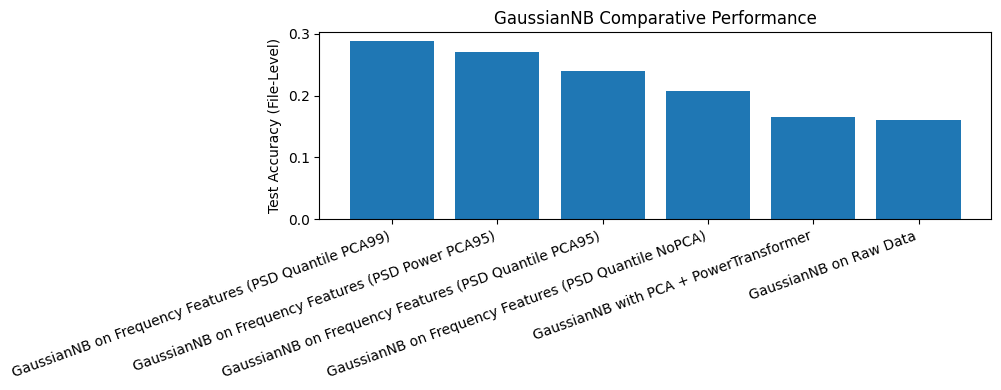

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

experiments = [
    ("GaussianNB on Raw Data", cached_raw, "none", None),
    ("GaussianNB with PCA + PowerTransformer", cached_raw, "power", 0.95),
    ("GaussianNB on Frequency Features (PSD Quantile PCA95)", cached_psd, "quantile", 0.95),
    ("GaussianNB on Frequency Features (PSD Power PCA95)", cached_psd, "power", 0.95),
    ("GaussianNB on Frequency Features (PSD Quantile NoPCA)", cached_psd, "quantile", None),
    ("GaussianNB on Frequency Features (PSD Quantile PCA99)", cached_psd, "quantile", 0.99),
]

results = []
artifacts = {}

for name, cd, gz, pca_v in experiments:
    out = run_experiment(name, cd, gz, pca_v)
    artifacts[name] = out
    results.append({
        "Experiment": out["name"],
        "Val_Acc_Window": out["val_acc_window"],
        "Test_Acc_Window": out["test_acc_window"],
        "Test_Acc_File": out["test_acc_file"],
        "Best_var_smoothing": out["best_var_smoothing"],
        "Dim_before": out["dim_before"],
        "Dim_after": out["dim_after"],
    })
    print(f"{name}: val={out['val_acc_window']:.4f}, test_win={out['test_acc_window']:.4f}, test_file={out['test_acc_file']:.4f}")

results_df = pd.DataFrame(results).sort_values("Test_Acc_File", ascending=False).reset_index(drop=True)
print(results_df)

plt.figure(figsize=(10, 4))
plt.bar(results_df["Experiment"], results_df["Test_Acc_File"])
plt.ylabel("Test Accuracy (File-Level)")
plt.title("GaussianNB Comparative Performance")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.svm import SVC

def run_svm_experiment(name, cached_data, gaussianizer="quantile", pca_var=0.95, c_grid=None):
    if c_grid is None:
        c_grid = [0.1, 1.0, 10.0, 100.0]

    X_tr, y_tr, fid_tr = cached_data["train"]
    X_va, y_va, fid_va = cached_data["val"]
    X_te, y_te, fid_te = cached_data["test"]

    prep_state, Xtr_p = fit_preprocess(X_tr, gaussianizer=gaussianizer, pca_var=pca_var)
    Xva_p = apply_preprocess(X_va, prep_state)

    best_c, best_val = None, -1.0
    for c in c_grid:
        clf = SVC(C=c, kernel="rbf", gamma="scale", class_weight="balanced")
        clf.fit(Xtr_p, y_tr)
        pred = clf.predict(Xva_p)
        acc = accuracy_score(y_va, pred)
        if acc > best_val:
            best_val = acc
            best_c = c

    X_tv = np.vstack([X_tr, X_va]).astype(np.float32)
    y_tv = np.concatenate([y_tr, y_va]).astype(np.int32)
    final_state, Xtv_p = fit_preprocess(X_tv, gaussianizer=gaussianizer, pca_var=pca_var)
    Xte_p = apply_preprocess(X_te, final_state)

    clf = SVC(C=best_c, kernel="rbf", gamma="scale", class_weight="balanced")
    clf.fit(Xtv_p, y_tv)
    y_pred = clf.predict(Xte_p)

    return {
        "name": name,
        "val_acc_window": best_val,
        "test_acc_window": accuracy_score(y_te, y_pred),
        "test_acc_file": file_level_metrics(y_te, y_pred, fid_te),
        "best_c": best_c,
        "dim_before": int(X_tr.shape[1]),
        "dim_after": int(Xtv_p.shape[1]),
        "model": clf,
        "preprocess_state": final_state,
    }

svm_out = run_svm_experiment(
    "SVM-RBF on Frequency Features (PSD)",
    cached_psd,
    gaussianizer="quantile",
    pca_var=0.95,
    c_grid=[0.1, 1.0, 10.0, 100.0]
)

print(svm_out)

artifacts[svm_out["name"]] = {
    "name": svm_out["name"],
    "val_acc_window": svm_out["val_acc_window"],
    "test_acc_window": svm_out["test_acc_window"],
    "test_acc_file": svm_out["test_acc_file"],
    "best_var_smoothing": np.nan,
    "dim_before": svm_out["dim_before"],
    "dim_after": svm_out["dim_after"],
    "model": svm_out["model"],
    "preprocess_state": svm_out["preprocess_state"],
}

{'name': 'SVM-RBF on Frequency Features (PSD)', 'val_acc_window': 0.6268698448203551, 'test_acc_window': 0.6753948462177889, 'test_acc_file': 0.8603351955307262, 'best_c': 100.0, 'dim_before': 128, 'dim_after': 32, 'model': SVC(C=100.0, class_weight='balanced'), 'preprocess_state': {'gaussianizer': 'quantile', 'transformer': QuantileTransformer(output_distribution='normal', random_state=42), 'mu': None, 'sd': None, 'pca': PCA(n_components=0.95, random_state=42, svd_solver='full')}}


                                          Experiment  Val_Acc_Window  \
0                SVM-RBF on Frequency Features (PSD)        0.626870   
1  GaussianNB on Frequency Features (PSD Quantile...        0.230113   
2  GaussianNB on Frequency Features (PSD Power PC...        0.224102   
3  GaussianNB on Frequency Features (PSD Quantile...        0.207465   
4  GaussianNB on Frequency Features (PSD Quantile...        0.176569   
5             GaussianNB with PCA + PowerTransformer        0.165805   
6                             GaussianNB on Raw Data        0.158814   

   Test_Acc_Window  Test_Acc_File  Best_var_smoothing  Dim_before  Dim_after  
0         0.675395       0.860335                 NaN         NaN        NaN  
1         0.247853       0.287709        1.000000e-10       128.0       60.0  
2         0.231643       0.269553        1.000000e-10       128.0       43.0  
3         0.218204       0.240223        1.000000e-10       128.0       32.0  
4         0.197977       0.2

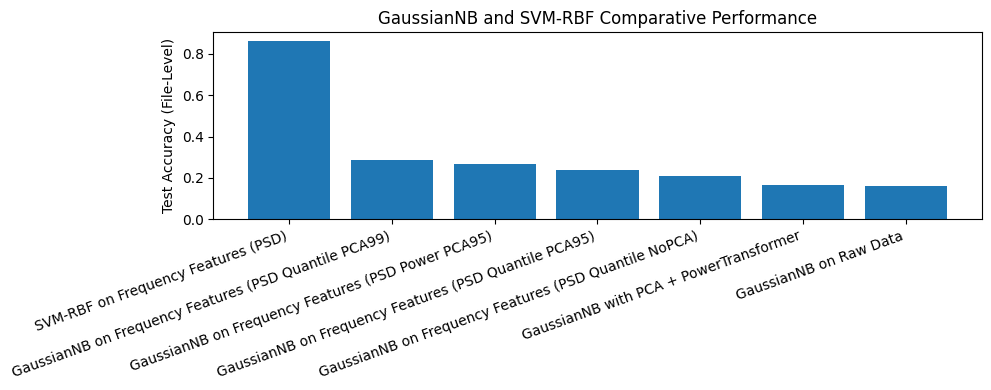

In [5]:
results.append({
    "Experiment": svm_out["name"],
    "Val_Acc_Window": svm_out["val_acc_window"],
    "Test_Acc_Window": svm_out["test_acc_window"],
    "Test_Acc_File": svm_out["test_acc_file"],
    "Best_var_smoothing": np.nan,
    "Dim_before": np.nan,
    "Dim_after": np.nan,
})

results_df = pd.DataFrame(results).sort_values("Test_Acc_File", ascending=False).reset_index(drop=True)
print(results_df)

plt.figure(figsize=(10, 4))
plt.bar(results_df["Experiment"], results_df["Test_Acc_File"])
plt.ylabel("Test Accuracy (File-Level)")
plt.title("GaussianNB and SVM-RBF Comparative Performance")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [7]:
from algorithm_gnb_jax import save_model

gnb_results_df = results_df[results_df["Best_var_smoothing"].notna()].reset_index(drop=True)
best_name = gnb_results_df.iloc[0]["Experiment"]
best_art = artifacts[best_name]
state = best_art["preprocess_state"]

meta = {
    "pipeline_name": best_name,
    "label_names": label_names,
    "window_size": window_size,
    "window_stride": window_stride,
    "sampling_rate": fs,
    "bands": bands,
    "best_var_smoothing": best_art["best_var_smoothing"],
    "gaussianizer": state["gaussianizer"],
    "mu": state["mu"],
    "sd": state["sd"],
    "transformer": state["transformer"],
    "pca": state["pca"],
    "train_medians": train_medians.to_dict(),
    "results_df": results_df.to_dict(orient="records"),
}

out_path = "gaussiannb_jax_model.pkl"
save_model(out_path, best_art["model"], meta)
print("Saved:", out_path, "using", best_name)

Saved: gaussiannb_jax_model.pkl using GaussianNB on Frequency Features (PSD Quantile PCA99)
